In [1]:
# ═══════════════════════════════════════════════════════
# Install Dependencies
# ═══════════════════════════════════════════════════════
!pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn tqdm
print("✓ Dependencies installed.")

✓ Dependencies installed.


In [2]:
# ═══════════════════════════════════════════════════════
# All Imports
# ═══════════════════════════════════════════════════════
import os, json, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.distributions import Categorical
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
from sklearn.metrics import f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✓ Imports done.")

✓ Imports done.


In [3]:

# ═══════════════════════════════════════════════════════════════
# All Classes & Functions

# ═══════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────
# Seed Utilities
# ──────────────────────────────────────────────────────────────
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ Seed set to {seed}")

# ──────────────────────────────────────────────────────────────
# Dataset Classes
# ──────────────────────────────────────────────────────────────
class BanglaABSADataset(Dataset):
    """For Baseline BanglaBERT"""
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row      = self.data.iloc[idx]
        encoding = self.tokenizer(
            row['text'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':       encoding['input_ids'].flatten(),
            'attention_mask':  encoding['attention_mask'].flatten(),
            'aspect_label':    torch.tensor(row['aspect_id'],    dtype=torch.long),
            'sentiment_label': torch.tensor(row['sentiment_id'], dtype=torch.long),
            'text':            row['text']
        }


class ABSADataset(Dataset):
    """For mBERT and RL-BanglaBERT — supports is_adversarial flag"""
    def __init__(self, df, tokenizer, max_length=128,
                 text_col='text', is_adversarial=False):
        self.data           = df.reset_index(drop=True)
        self.tokenizer      = tokenizer
        self.max_length     = max_length
        self.text_col       = text_col
        self.is_adversarial = is_adversarial

        if text_col not in self.data.columns:
            raise ValueError(
                f"Column '{text_col}' not found. "
                f"Available: {self.data.columns.tolist()}"
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(
            row[self.text_col],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':       enc['input_ids'].flatten(),
            'attention_mask':  enc['attention_mask'].flatten(),
            'aspect_label':    torch.tensor(row['aspect_id'],    dtype=torch.long),
            'sentiment_label': torch.tensor(row['sentiment_id'], dtype=torch.long),
            'is_adversarial':  torch.tensor(
                                   1.0 if self.is_adversarial else 0.0,
                                   dtype=torch.float)
        }

# ──────────────────────────────────────────────────────────────
# Model Definitions
# ──────────────────────────────────────────────────────────────
class BanglaBERTForABSA(nn.Module):
    """Baseline BanglaBERT model"""
    def __init__(self, model_name="sagorsarker/bangla-bert-base",
                 num_aspects=5, num_sentiments=3, dropout=0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        hidden_size     = self.bert.config.hidden_size  # 768

        self.aspect_classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_aspects)
        )
        self.sentiment_classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_sentiments)
        )

    def forward(self, input_ids, attention_mask):
        outputs      = self.bert(input_ids=input_ids,
                                 attention_mask=attention_mask)
        pooled       = outputs.last_hidden_state[:, 0, :]  # [CLS]
        aspect_logits    = self.aspect_classifier(pooled)
        sentiment_logits = self.sentiment_classifier(pooled)
        return aspect_logits, sentiment_logits


class mBERTForABSA(nn.Module):
    """Multilingual BERT model"""
    def __init__(self, num_aspects, num_sentiments):
        super().__init__()
        self.bert = AutoModel.from_pretrained("bert-base-multilingual-cased")
        hidden    = self.bert.config.hidden_size

        self.aspect_classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden, num_aspects)
        )
        self.sentiment_classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden, num_sentiments)
        )

    def forward(self, input_ids, attention_mask):
        outputs          = self.bert(input_ids=input_ids,
                                     attention_mask=attention_mask)
        pooled           = outputs.pooler_output
        aspect_logits    = self.aspect_classifier(pooled)
        sentiment_logits = self.sentiment_classifier(pooled)
        return aspect_logits, sentiment_logits


class BanglaBERTForRL(nn.Module):
    """BanglaBERT with value head for PPO"""
    def __init__(self, model_name, num_aspects, num_sentiments, dropout=0.1):
        super().__init__()
        self.bert  = AutoModel.from_pretrained(model_name)
        hidden     = self.bert.config.hidden_size  # 768

        def _head(out_dim):
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden // 2),
                nn.LayerNorm(hidden // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 2, out_dim)
            )

        self.aspect_classifier    = _head(num_aspects)
        self.sentiment_classifier = _head(num_sentiments)
        self.value_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, input_ids, attention_mask):
        out   = self.bert(input_ids=input_ids,
                          attention_mask=attention_mask)
        cls   = out.last_hidden_state[:, 0, :]
        return (self.aspect_classifier(cls),
                self.sentiment_classifier(cls),
                self.value_head(cls).squeeze(-1))

# ──────────────────────────────────────────────────────────────
# Evaluation Functions
# ──────────────────────────────────────────────────────────────
def evaluate_baseline(model, data_loader, device,
                      aspect_criterion, sentiment_criterion,
                      desc='Evaluating'):
    """
    Evaluation for Baseline BanglaBERT.
    Returns: avg_loss, combined_accuracy, avg_f1
    """
    model.eval()
    total_loss = 0
    all_aspect_preds,  all_aspect_labels = [], []
    all_sent_preds,    all_sent_labels   = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=desc):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            aspect_lab     = batch['aspect_label'].to(device)
            sent_lab       = batch['sentiment_label'].to(device)

            aspect_logits, sent_logits = model(input_ids, attention_mask)

            loss = aspect_criterion(aspect_logits, aspect_lab) + \
                   sentiment_criterion(sent_logits, sent_lab)
            total_loss += loss.item()

            aspect_preds = torch.argmax(aspect_logits, dim=1)
            sent_preds   = torch.argmax(sent_logits,   dim=1)

            all_aspect_preds.extend(aspect_preds.cpu().numpy())
            all_aspect_labels.extend(aspect_lab.cpu().numpy())
            all_sent_preds.extend(sent_preds.cpu().numpy())
            all_sent_labels.extend(sent_lab.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    combined_acc = float(np.mean(
        (np.array(all_aspect_preds) == np.array(all_aspect_labels)) &
        (np.array(all_sent_preds)   == np.array(all_sent_labels))
    ))
    aspect_f1   = f1_score(all_aspect_labels, all_aspect_preds,
                           average='weighted', zero_division=0)
    sent_f1     = f1_score(all_sent_labels,   all_sent_preds,
                           average='weighted', zero_division=0)
    avg_f1      = (aspect_f1 + sent_f1) / 2

    return avg_loss, combined_acc, avg_f1


def evaluate_rl(model, dataloader, device, desc="Eval"):
    """
    Evaluation for mBERT and RL-BanglaBERT.
    Returns: dict with accuracy, f1, aspect_f1, sentiment_f1
    """
    model.eval()
    all_ap, all_al, all_sp, all_sl = [], [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc, leave=False):
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            al     = batch['aspect_label'].to(device)
            sl     = batch['sentiment_label'].to(device)

            # Works for both mBERT (2 outputs) and RL model (3 outputs)
            outputs = model(ids, mask)
            alogits = outputs[0]
            slogits = outputs[1]

            all_ap.extend(torch.argmax(alogits, 1).cpu().numpy())
            all_al.extend(al.cpu().numpy())
            all_sp.extend(torch.argmax(slogits, 1).cpu().numpy())
            all_sl.extend(sl.cpu().numpy())

    all_ap, all_al = np.array(all_ap), np.array(all_al)
    all_sp, all_sl = np.array(all_sp), np.array(all_sl)

    combined_acc = float(np.mean(
        (all_ap == all_al) & (all_sp == all_sl)
    ))
    aspect_f1 = f1_score(all_al, all_ap,
                         average='weighted', zero_division=0)
    sent_f1   = f1_score(all_sl, all_sp,
                         average='weighted', zero_division=0)
    avg_f1    = (aspect_f1 + sent_f1) / 2.0

    model.train()
    return {
        'accuracy':     combined_acc,
        'f1':           avg_f1,
        'aspect_f1':    aspect_f1,
        'sentiment_f1': sent_f1
    }

# ──────────────────────────────────────────────────────────────
# Training Functions
# ──────────────────────────────────────────────────────────────
def train_baseline(model, train_loader, val_loader,
                   config, device, save_path):
    """
    Supervised CE training for Baseline BanglaBERT.
    """
    aspect_criterion    = nn.CrossEntropyLoss()
    sentiment_criterion = nn.CrossEntropyLoss()

    optimizer    = AdamW(model.parameters(), lr=config['learning_rate'])
    total_steps  = len(train_loader) * config['epochs']
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = total_steps // 10,
        num_training_steps = total_steps
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [], 'val_f1': []
    }
    best_val_acc = 0

    for epoch in range(config['epochs']):
        print(f"\n{'='*60}\nEpoch {epoch+1}/{config['epochs']}\n{'='*60}")

        # ── Train ──
        model.train()
        train_loss = 0
        train_correct = train_total = 0

        pbar = tqdm(train_loader, desc='Training')
        for batch in pbar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            aspect_lab     = batch['aspect_label'].to(device)
            sent_lab       = batch['sentiment_label'].to(device)

            optimizer.zero_grad()
            aspect_logits, sent_logits = model(input_ids, attention_mask)
            loss = aspect_criterion(aspect_logits, aspect_lab) + \
                   sentiment_criterion(sent_logits, sent_lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            aspect_p    = torch.argmax(aspect_logits, dim=1)
            sent_p      = torch.argmax(sent_logits,   dim=1)
            correct     = ((aspect_p == aspect_lab) &
                           (sent_p   == sent_lab)).sum().item()
            train_correct += correct
            train_total   += input_ids.size(0)
            pbar.set_postfix(
                loss=f'{loss.item():.4f}',
                acc =f'{correct/input_ids.size(0):.4f}'
            )

        avg_train_loss = train_loss / len(train_loader)
        train_acc      = train_correct / train_total

        # ── Validate ──
        val_loss, val_acc, val_f1 = evaluate_baseline(
            model, val_loader, device,
            aspect_criterion, sentiment_criterion
        )

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}   | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch':               epoch,
                'model_state_dict':    model.state_dict(),
                'optimizer_state_dict':optimizer.state_dict(),
                'val_acc':             val_acc,
                'val_f1':              val_f1
            }, save_path)          
            print(f"  ✓ Best model saved → {save_path} (Val Acc: {val_acc:.4f})")

    return history


def train_mbert(model, train_loader, val_loader,
                device, save_path):
    """
    Supervised CE training for mBERT.
    """
    a_crit    = nn.CrossEntropyLoss()
    s_crit    = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=2e-5)
    best_val_acc = 0

    for epoch in range(5):
        print(f"\n{'='*60}\nEpoch {epoch+1}/5\n{'='*60}")
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc='Training'):
            ids      = batch['input_ids'].to(device)
            mask     = batch['attention_mask'].to(device)
            a_labels = batch['aspect_label'].to(device)
            s_labels = batch['sentiment_label'].to(device)

            optimizer.zero_grad()
            a_logits, s_logits = model(ids, mask)
            loss = a_crit(a_logits, a_labels) + \
                   s_crit(s_logits, s_labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        val_results = evaluate_rl(model, val_loader, device,
                                  desc="Validating")
        val_acc = val_results['accuracy']
        val_f1  = val_results['f1']

        print(f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch':            epoch,
                'model_state_dict': model.state_dict(),
                'val_acc':          val_acc,
                'val_f1':           val_f1
            }, save_path)         
            print(f"  ✓ Best model saved → {save_path}")

    print(f"\n✓ mBERT training done. Best val acc: {best_val_acc:.4f}")


def train_rl(model, reference_model,
             train_clean_loader, train_adv_loader,
             val_clean_loader, val_adv_loader,
             config, device, save_path):
    """
    Hybrid CE + PPO training for RL-BanglaBERT.
    """
    from itertools import cycle

    # ── Trainer class  ──
    class HybridRLTrainer:
        def __init__(self, model, reference_model, config, device):
            self.model           = model
            self.reference_model = reference_model
            self.config          = config
            self.device          = device
            self.optimizer = AdamW(
                model.parameters(),
                lr=config['rl_lr'],
                weight_decay=config['weight_decay']
            )
            self.ce_loss = nn.CrossEntropyLoss()

        def clean_step(self, batch):
            ids   = batch['input_ids'].to(self.device)
            mask  = batch['attention_mask'].to(self.device)
            a_lab = batch['aspect_label'].to(self.device)
            s_lab = batch['sentiment_label'].to(self.device)

            a_logits, s_logits, _ = self.model(ids, mask)
            ce  = self.ce_loss(a_logits, a_lab) + \
                  self.ce_loss(s_logits, s_lab)
            kl  = self._kl_loss(ids, mask, a_logits, s_logits)
            return ce + self.config['kl_coef'] * kl, \
                   {'ce_loss': ce.item(), 'kl_loss': kl.item()}

        def adversarial_step(self, batch):
            ids    = batch['input_ids'].to(self.device)
            mask   = batch['attention_mask'].to(self.device)
            a_lab  = batch['aspect_label'].to(self.device)
            s_lab  = batch['sentiment_label'].to(self.device)
            is_adv = batch['is_adversarial'].to(self.device)

            a_logits, s_logits, values = self.model(ids, mask)
            a_probs = torch.softmax(a_logits, dim=-1)
            s_probs = torch.softmax(s_logits, dim=-1)
            a_dist  = Categorical(a_probs)
            s_dist  = Categorical(s_probs)
            a_actions = a_dist.sample()
            s_actions = s_dist.sample()

            rewards    = self._compute_rewards(
                a_actions, a_lab, s_actions, s_lab,
                is_adv, a_probs, s_probs
            )
            advantages = rewards - values.detach()
            advantages = (advantages - advantages.mean()) / \
                         (advantages.std() + 1e-8)

            log_probs     = a_dist.log_prob(a_actions) + \
                            s_dist.log_prob(s_actions)
            old_log_probs = log_probs.detach()
            ratio         = torch.exp(log_probs - old_log_probs)
            clipped       = torch.clamp(
                ratio,
                1 - self.config['clip_range'],
                1 + self.config['clip_range']
            )
            policy_loss  = -torch.min(ratio * advantages,
                                      clipped * advantages).mean()
            value_loss   = self.config['value_coef'] * \
                           ((rewards - values) ** 2).mean()
            entropy      = (a_dist.entropy() +
                            s_dist.entropy()).mean()
            entropy_loss = -self.config['entropy_coef'] * entropy
            kl           = self._kl_loss(ids, mask, a_logits, s_logits)

            ppo_loss = policy_loss + value_loss + entropy_loss
            total    = ppo_loss + self.config['kl_coef'] * kl
            return total, {
                'ppo_loss':    ppo_loss.item(),
                'kl_loss':     kl.item(),
                'reward_mean': rewards.mean().item()
            }

        def _kl_loss(self, ids, mask, a_logits, s_logits):
            with torch.no_grad():
                ref_a, ref_s, _ = self.reference_model(ids, mask)
            kl_a = F.kl_div(
                F.log_softmax(a_logits, dim=-1),
                F.softmax(ref_a.detach(), dim=-1),
                reduction='batchmean'
            )
            kl_s = F.kl_div(
                F.log_softmax(s_logits, dim=-1),
                F.softmax(ref_s.detach(), dim=-1),
                reduction='batchmean'
            )
            return (kl_a + kl_s) * 0.5

        def _compute_rewards(self, a_preds, a_labs,
                              s_preds, s_labs,
                              is_adv, a_probs, s_probs):
            a_correct  = (a_preds == a_labs).float()
            s_correct  = (s_preds == s_labs).float()
            both       = a_correct * s_correct
            base       = a_correct + s_correct + both

            clean_scale = self.config['clean_reward_scale']
            adv_scale   = self.config['adversarial_reward_scale']
            scale       = torch.where(
                is_adv.bool(),
                torch.full_like(is_adv, adv_scale),
                torch.full_like(is_adv, clean_scale)
            )
            rewards    = base * scale

            a_conf     = a_probs.gather(
                1, a_preds.unsqueeze(1)).squeeze()
            s_conf     = s_probs.gather(
                1, s_preds.unsqueeze(1)).squeeze()
            conf_bonus = (a_conf + s_conf) / 2.0
            rewards   += self.config['margin_bonus'] * both * conf_bonus

            both_wrong = (1 - a_correct) * (1 - s_correct)
            rewards   -= 0.5 * both_wrong
            return rewards

    # ── Training loop ──
    trainer  = HybridRLTrainer(model, reference_model, config, device)
    adv_iter = cycle(train_adv_loader)

    history = {
        'epoch':          [],
        'val_clean_acc':  [], 'val_clean_f1': [],
        'val_adv_acc':    [], 'val_adv_f1':   [],
        'robustness':     [], 'combined_score': []
    }

    best_combined_score = 0.0
    patience_counter    = 0
    best_epoch          = -1

    for epoch in range(config['rl_epochs']):
        print(f"\n{'═'*60}")
        print(f"  Epoch {epoch+1}/{config['rl_epochs']}")
        print(f"{'═'*60}")

        model.train()
        ce_losses, ppo_losses, kl_losses = [], [], []

        pbar = tqdm(train_clean_loader, desc='Training', leave=True)
        for clean_batch in pbar:
            # ── Clean supervised step ──
            trainer.optimizer.zero_grad()
            clean_loss, clean_metrics = trainer.clean_step(clean_batch)
            clean_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            trainer.optimizer.step()
            ce_losses.append(clean_metrics['ce_loss'])
            kl_losses.append(clean_metrics['kl_loss'])

            # ── Adversarial PPO step ──
            adv_batch = next(adv_iter)
            trainer.optimizer.zero_grad()
            adv_loss, adv_metrics = trainer.adversarial_step(adv_batch)
            adv_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            trainer.optimizer.step()
            ppo_losses.append(adv_metrics['ppo_loss'])

            pbar.set_postfix({
                'ce':  f"{clean_metrics['ce_loss']:.3f}",
                'ppo': f"{adv_metrics['ppo_loss']:.3f}",
                'kl':  f"{clean_metrics['kl_loss']:.3f}",
                'rew': f"{adv_metrics['reward_mean']:.3f}",
            })

        # ── Validation ──
        val_clean = evaluate_rl(model, val_clean_loader,
                                device, "Val-Clean")
        val_adv   = evaluate_rl(model, val_adv_loader,
                                device, "Val-Adv  ")
        robustness     = val_adv['accuracy'] / \
                         (val_clean['accuracy'] + 1e-8)
        combined_score = val_clean['accuracy'] + 0.3 * robustness

        print(f"\n  Results:")
        print(f"    CE Loss:    {np.mean(ce_losses):.4f}")
        print(f"    PPO Loss:   {np.mean(ppo_losses):.4f}")
        print(f"    KL Loss:    {np.mean(kl_losses):.4f}")
        print(f"    Clean Acc:  {val_clean['accuracy']:.4f}  "
              f"(floor: {config['clean_acc_floor']:.4f})")
        print(f"    Adv Acc:    {val_adv['accuracy']:.4f}")
        print(f"    Clean F1:   {val_clean['f1']:.4f}")
        print(f"    Adv F1:     {val_adv['f1']:.4f}")
        print(f"    Robustness: {robustness:.4f}")
        print(f"    Combined:   {combined_score:.4f}")

        history['epoch'].append(epoch + 1)
        history['val_clean_acc'].append(val_clean['accuracy'])
        history['val_clean_f1'].append(val_clean['f1'])
        history['val_adv_acc'].append(val_adv['accuracy'])
        history['val_adv_f1'].append(val_adv['f1'])
        history['robustness'].append(robustness)
        history['combined_score'].append(combined_score)

        # ── Constrained save ──
        clean_ok = val_clean['accuracy'] >= config['clean_acc_floor']
        if clean_ok and combined_score > best_combined_score:
            best_combined_score = combined_score
            best_epoch          = epoch + 1
            torch.save({
                'epoch':               epoch,
                'model_state_dict':    model.state_dict(),
                'optimizer_state_dict':trainer.optimizer.state_dict(),
                'val_clean_acc':       val_clean['accuracy'],
                'val_adv_acc':         val_adv['accuracy'],
                'val_clean_f1':        val_clean['f1'],
                'val_adv_f1':          val_adv['f1'],
                'robustness':          robustness,
                'combined_score':      combined_score,
            }, save_path)           
            print(f"  ✓ Best model saved → {save_path} "
                  f"(epoch {best_epoch}, "
                  f"combined={combined_score:.4f})")
            patience_counter = 0
        else:
            if not clean_ok:
                print(f"  ✗ Skipped — clean acc "
                      f"{val_clean['accuracy']:.4f} "
                      f"below floor {config['clean_acc_floor']:.4f}")
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"\n  Early stopping triggered.")
                break

        torch.cuda.empty_cache()

    print(f"\n  Training complete! Best epoch: {best_epoch}")
    print(f"  Best combined score: {best_combined_score:.4f}")
    return history


print("✓ All classes and functions defined. Ready to train.")


✓ All classes and functions defined. Ready to train.


In [4]:
# ═══════════════════════════════════════════════════════
# Data Paths & Config

# ═══════════════════════════════════════════════════════
BASE             = "/kaggle/input/datasets/jebafawjia/processed-bangla-datasets/"
BASE_ADVERSARIAL = "/kaggle/input/datasets/jebafawjia/all-adversarial-datasets/"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

# Load label mappings 
with open(BASE + "label_mappings.json", 'r', encoding='utf-8') as f:
    labels = json.load(f)

# Load raw dataframes 
train_df     = pd.read_csv(BASE + "train.csv")
val_df       = pd.read_csv(BASE + "val.csv")
test_df      = pd.read_csv(BASE + "test.csv")
adv_full_df  = pd.read_csv(BASE_ADVERSARIAL + "train_with_adversarial.csv")
adv_df       = adv_full_df[adv_full_df['is_adversarial'] == True].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Adversarial: {len(adv_df)}")

# Tokenizers  
tokenizer_bangla = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
tokenizer_mbert  = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

# Configs
baseline_config = {
    'epochs': 10,
    'learning_rate': 1e-5,
    'batch_size': 16,
    'max_length': 128
}

rl_config = {
    'rl_epochs': 20,
    'rl_lr': 5e-6,
    'batch_size': 32,
    'max_length': 128,
    'adversarial_ratio': 0.3,
    'ppo_epochs': 1,
    'clip_range': 0.1,
    'entropy_coef': 0.01,
    'value_coef': 0.5,
    'clean_reward_scale': 1.8,
    'adversarial_reward_scale': 1.2,
    'margin_bonus': 0.15,
    'kl_coef': 0.4,
    'weight_decay': 0.01,
    'dropout': 0.1,
    'patience': 8,
    'clean_acc_tolerance': 0.01,
}

print("✓ Config and data ready.")

Device: cuda
Train: 2819 | Val: 604 | Test: 605
Adversarial: 520


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Config and data ready.


In [5]:
# ═══════════════════════════════════════════════════════
# SEED 42 — For ALL 3 MODELS
# ═══════════════════════════════════════════════════════
SEED = 42
set_seed(SEED)

g = torch.Generator()
g.manual_seed(SEED)

# ── DataLoaders ──
train_loader_b = DataLoader(
    BanglaABSADataset(train_df, tokenizer_bangla),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_b = DataLoader(
    BanglaABSADataset(val_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_b = DataLoader(
    BanglaABSADataset(test_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)

# ────────────────────────────────
# 1. BASELINE
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — BASELINE BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)  # reset seed right before model init
baseline_model_s42 = BanglaBERTForABSA(
    num_aspects=labels['num_aspects'],
    num_sentiments=labels['num_sentiments']
).to(device)

train_baseline(
    baseline_model_s42, train_loader_b, val_loader_b,
    baseline_config, device,
    save_path=f'models/baseline_seed{SEED}.pt'
)

# Test evaluation
ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_model_s42.load_state_dict(ckpt['model_state_dict'])
a_crit = nn.CrossEntropyLoss()
s_crit = nn.CrossEntropyLoss()
_, b_clean_acc_s42, b_clean_f1_s42 = evaluate_baseline(
    baseline_model_s42, test_loader_b, device, a_crit, s_crit, desc='Baseline Test')
_, b_adv_acc_s42, b_adv_f1_s42 = evaluate_baseline(
    baseline_model_s42,
    DataLoader(BanglaABSADataset(adv_df, tokenizer_bangla), batch_size=16),
    device, a_crit, s_crit, desc='Baseline Adv Test')
b_rob_s42 = b_adv_acc_s42 / b_clean_acc_s42

print(f"\nBaseline Seed {SEED}: Clean={b_clean_acc_s42:.4f} | Adv={b_adv_acc_s42:.4f} | Rob={b_rob_s42:.4f}")

# ────────────────────────────────
# 2. mBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — mBERT")
print(f"{'='*60}")

set_seed(SEED)
train_loader_m = DataLoader(
    BanglaABSADataset(train_df, tokenizer_mbert),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_m   = DataLoader(
    BanglaABSADataset(val_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_m  = DataLoader(
    BanglaABSADataset(test_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
adv_loader_m   = DataLoader(
    BanglaABSADataset(adv_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)

mbert_model_s42 = mBERTForABSA(
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

train_mbert(
    mbert_model_s42, train_loader_m, val_loader_m,
    device, save_path=f'models/mbert_seed{SEED}.pt'
)
# ── Load best mBERT checkpoint ──
ckpt = torch.load(f'models/mbert_seed{SEED}.pt', weights_only=False)
mbert_model_s42.load_state_dict(ckpt['model_state_dict'])  

m_clean_results_s42 = evaluate_rl(
    mbert_model_s42, test_loader_m, device, desc='mBERT Test')
m_adv_results_s42 = evaluate_rl(
    mbert_model_s42, adv_loader_m, device, desc='mBERT Adv')

m_clean_acc_s42 = m_clean_results_s42['accuracy']
m_clean_f1_s42  = m_clean_results_s42['f1']
m_adv_acc_s42   = m_adv_results_s42['accuracy']
m_adv_f1_s42    = m_adv_results_s42['f1']
m_rob_s42       = m_adv_acc_s42 / m_clean_acc_s42

print(f"\nmBERT Seed {SEED}: Clean={m_clean_acc_s42:.4f} | Adv={m_adv_acc_s42:.4f} | Rob={m_rob_s42:.4f}")
# ────────────────────────────────
# 3. RL-BanglaBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — RL-BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)
rl_model_s42 = BanglaBERTForRL(
    "sagorsarker/bangla-bert-base",
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

# Load from matching baseline checkpoint
baseline_ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_weights = baseline_ckpt['model_state_dict']
model_dict = rl_model_s42.state_dict()
compatible = {k: v for k, v in baseline_weights.items()
              if k in model_dict and v.shape == model_dict[k].shape}
model_dict.update(compatible)
rl_model_s42.load_state_dict(model_dict, strict=False)
print(f"  ✓ Loaded baseline checkpoint ({len(compatible)}/{len(model_dict)} weights)")

rl_config['clean_acc_floor'] = baseline_ckpt.get('val_acc', 0.93) - rl_config['clean_acc_tolerance']

reference_model_s42 = copy.deepcopy(rl_model_s42)
reference_model_s42.eval()
for p in reference_model_s42.parameters():
    p.requires_grad = False

# Build RL dataloaders
adv_sample = adv_df.sample(n=min(520, len(adv_df)), random_state=SEED)
adv_eval   = adv_df.sample(n=min(500, len(adv_df)), random_state=SEED)

train_clean_loader_rl = DataLoader(
    ABSADataset(train_df, tokenizer_bangla, is_adversarial=False),
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

train_adv_loader_rl = DataLoader(
    ABSADataset(adv_sample, tokenizer_bangla, is_adversarial=True),
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

val_clean_loader_rl = DataLoader(
    ABSADataset(val_df, tokenizer_bangla, is_adversarial=False),
    batch_size=32, shuffle=False, num_workers=2)

val_adv_loader_rl = DataLoader(
    ABSADataset(adv_eval, tokenizer_bangla, is_adversarial=True),
    batch_size=32, shuffle=False, num_workers=2)

# Test loaders for final evaluation
test_clean_loader_rl = DataLoader(
    ABSADataset(test_df, tokenizer_bangla, is_adversarial=False),
    batch_size=32, shuffle=False, num_workers=2)

train_rl(
    rl_model_s42, reference_model_s42,
    train_clean_loader_rl, train_adv_loader_rl,
    val_clean_loader_rl, val_adv_loader_rl,
    rl_config, device,
    save_path=f'models/rl_banglabert_seed{SEED}.pt'
)

rl_ckpt = torch.load(f'models/rl_banglabert_seed{SEED}.pt', weights_only=False)
rl_model_s42.load_state_dict(rl_ckpt['model_state_dict'])

rl_clean_s42 = evaluate_rl(rl_model_s42, test_clean_loader_rl, device, desc='RL Clean Test') 
rl_adv_s42   = evaluate_rl(rl_model_s42, val_adv_loader_rl,   device, desc='RL Adv Test')
rl_rob_s42   = rl_adv_s42['accuracy'] / rl_clean_s42['accuracy']
print(f"\nRL Seed {SEED}: Clean={rl_clean_s42['accuracy']:.4f} | Adv={rl_adv_s42['accuracy']:.4f} | Rob={rl_rob_s42:.4f}")



import gc

print("\nCleaning up GPU memory after seed 42...")

# Delete all seed 42 models from GPU
del baseline_model_s42
del mbert_model_s42
del rl_model_s42
del reference_model_s42

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Confirm memory freed
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print("✓ GPU memory cleared. Ready for seed 123.")



✓ Seed set to 42

  SEED 42 — BASELINE BANGLABERT
✓ Seed set to 42


model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/10


...

Training: 100%|██████████| 89/89 [02:42<00:00,  1.83s/it, ce=0.009, ppo=0.213, kl=0.005, rew=3.589]



  Results:
    CE Loss:    0.0464
    PPO Loss:   0.1285
    KL Loss:    0.0257
    Clean Acc:  0.9272  (floor: 0.9287)
    Adv Acc:    0.9820
    Clean F1:   0.9624
    Adv F1:     0.9900
    Robustness: 1.0592
    Combined:   1.2449
  ✗ Skipped — clean acc 0.9272 below floor 0.9287

════════════════════════════════════════════════════════════
  Epoch 12/20
════════════════════════════════════════════════════════════


Training: 100%|██████████| 89/89 [02:42<00:00,  1.83s/it, ce=0.007, ppo=0.255, kl=0.005, rew=3.510]



  Results:
    CE Loss:    0.0397
    PPO Loss:   0.1131
    KL Loss:    0.0264
    Clean Acc:  0.9288  (floor: 0.9287)
    Adv Acc:    0.9760
    Clean F1:   0.9634
    Adv F1:     0.9860
    Robustness: 1.0508
    Combined:   1.2441

  Early stopping triggered.

  Training complete! Best epoch: 4
  Best combined score: 1.2455



RL Seed 42: Clean=0.9504 | Adv=0.9600 | Rob=1.0101

Cleaning up GPU memory after seed 42...
GPU memory allocated: 4.40 GB
GPU memory reserved:  9.44 GB
✓ GPU memory cleared. Ready for seed 123.


In [6]:
# ═══════════════════════════════════════════════════════
# SEED 123 — For ALL 3 MODELS

# ═══════════════════════════════════════════════════════
SEED = 123
set_seed(SEED)


g = torch.Generator()
g.manual_seed(SEED)

# ── DataLoaders ──
train_loader_b = DataLoader(
    BanglaABSADataset(train_df, tokenizer_bangla),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_b = DataLoader(
    BanglaABSADataset(val_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_b = DataLoader(
    BanglaABSADataset(test_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)

# ────────────────────────────────
# 1. BASELINE
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — BASELINE BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)  # reset seed right before model init
baseline_model_s123 = BanglaBERTForABSA(
    num_aspects=labels['num_aspects'],
    num_sentiments=labels['num_sentiments']
).to(device)

train_baseline(
    baseline_model_s123, train_loader_b, val_loader_b,
    baseline_config, device,
    save_path=f'models/baseline_seed{SEED}.pt'
)

# Test evaluation
ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_model_s123.load_state_dict(ckpt['model_state_dict'])
a_crit = nn.CrossEntropyLoss()
s_crit = nn.CrossEntropyLoss()
_, b_clean_acc_s123, b_clean_f1_s123 = evaluate_baseline(
    baseline_model_s123, test_loader_b, device, a_crit, s_crit, desc='Baseline Test')
_, b_adv_acc_s123, b_adv_f1_s123 = evaluate_baseline(
    baseline_model_s123,
    DataLoader(BanglaABSADataset(adv_df, tokenizer_bangla), batch_size=16),
    device, a_crit, s_crit, desc='Baseline Adv Test')
b_rob_s123 = b_adv_acc_s123 / b_clean_acc_s123

print(f"\nBaseline Seed {SEED}: Clean={b_clean_acc_s123:.4f} | Adv={b_adv_acc_s123:.4f} | Rob={b_rob_s123:.4f}")

# ────────────────────────────────
# 2. mBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — mBERT")
print(f"{'='*60}")

set_seed(SEED)
train_loader_m = DataLoader(
    BanglaABSADataset(train_df, tokenizer_mbert),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_m   = DataLoader(
    BanglaABSADataset(val_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_m  = DataLoader(
    BanglaABSADataset(test_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
adv_loader_m   = DataLoader(
    BanglaABSADataset(adv_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)

mbert_model_s123 = mBERTForABSA(
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

train_mbert(
    mbert_model_s123, train_loader_m, val_loader_m,
    device, save_path=f'models/mbert_seed{SEED}.pt'
)


# ── Load best mBERT checkpoint ──
ckpt = torch.load(f'models/mbert_seed{SEED}.pt', weights_only=False)
mbert_model_s123.load_state_dict(ckpt['model_state_dict']) 

m_clean_results_s123 = evaluate_rl(
    mbert_model_s123, test_loader_m, device, desc='mBERT Test')
m_adv_results_s123 = evaluate_rl(
    mbert_model_s123, adv_loader_m, device, desc='mBERT Adv')

m_clean_acc_s123 = m_clean_results_s123['accuracy']
m_clean_f1_s123  = m_clean_results_s123['f1']
m_adv_acc_s123  = m_adv_results_s123['accuracy']
m_adv_f1_s123   = m_adv_results_s123['f1']
m_rob_s123       = m_adv_acc_s123 / m_clean_acc_s123

print(f"\nmBERT Seed {SEED}: Clean={m_clean_acc_s123:.4f} | Adv={m_adv_acc_s123:.4f} | Rob={m_rob_s123:.4f}")

# ────────────────────────────────
# 3. RL-BanglaBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — RL-BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)
rl_model_s123 = BanglaBERTForRL(
    "sagorsarker/bangla-bert-base",
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

# Load from matching baseline checkpoint
baseline_ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_weights = baseline_ckpt['model_state_dict']
model_dict = rl_model_s123.state_dict()
compatible = {k: v for k, v in baseline_weights.items()
              if k in model_dict and v.shape == model_dict[k].shape}
model_dict.update(compatible)
rl_model_s123.load_state_dict(model_dict, strict=False)
print(f"  ✓ Loaded baseline checkpoint ({len(compatible)}/{len(model_dict)} weights)")

rl_config['clean_acc_floor'] = baseline_ckpt.get('val_acc', 0.93) - rl_config['clean_acc_tolerance']

reference_model_s123 = copy.deepcopy(rl_model_s123)
reference_model_s123.eval()
for p in reference_model_s123.parameters():
    p.requires_grad = False

# ── Build RL DataLoaders (seed 123) ──
adv_sample = adv_df.sample(n=min(520, len(adv_df)), random_state=SEED)
adv_eval   = adv_df.sample(n=min(500, len(adv_df)), random_state=SEED)

train_clean_loader_rl = DataLoader(
    ABSADataset(train_df, tokenizer_bangla, is_adversarial=False),  # ABSADataset
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

train_adv_loader_rl = DataLoader(
    ABSADataset(adv_sample, tokenizer_bangla, is_adversarial=True),  # ABSADataset
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

val_clean_loader_rl = DataLoader(
    ABSADataset(val_df, tokenizer_bangla, is_adversarial=False),  # ABSADataset + is_adversarial
    batch_size=32, shuffle=False, num_workers=2)

val_adv_loader_rl = DataLoader(
    ABSADataset(adv_eval, tokenizer_bangla, is_adversarial=True),  # ABSADataset
    batch_size=32, shuffle=False, num_workers=2)

test_clean_loader_rl = DataLoader(
    ABSADataset(test_df, tokenizer_bangla, is_adversarial=False),  # for final test
    batch_size=32, shuffle=False, num_workers=2)

train_rl(
    rl_model_s123, reference_model_s123,
    train_clean_loader_rl, train_adv_loader_rl,
    val_clean_loader_rl, val_adv_loader_rl,
    rl_config, device,
    save_path=f'models/rl_banglabert_seed{SEED}.pt'
)

rl_ckpt = torch.load(f'models/rl_banglabert_seed{SEED}.pt', weights_only=False)
rl_model_s123.load_state_dict(rl_ckpt['model_state_dict'])

rl_clean_s123 = evaluate_rl(rl_model_s123, test_clean_loader_rl, device, desc='RL Clean Test')  # test_clean_loader_rl
rl_adv_s123   = evaluate_rl(rl_model_s123, val_adv_loader_rl,   device, desc='RL Adv Test')
rl_rob_s123   = rl_adv_s123['accuracy'] / rl_clean_s123['accuracy']

print(f"\nRL Seed {SEED}: Clean={rl_clean_s123['accuracy']:.4f} | Adv={rl_adv_s123['accuracy']:.4f} | Rob={rl_rob_s123:.4f}")

# ═══════════════════════════════════════════════════════
# END OF SEED 123 — CLEANUP GPU MEMORY

# ═══════════════════════════════════════════════════════

print("\nCleaning up GPU memory after seed 123...")

del baseline_model_s123
del mbert_model_s123
del rl_model_s123
del reference_model_s123

torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print("✓ GPU memory cleared. Ready for seed 456.")




✓ Seed set to 123

  SEED 123 — BASELINE BANGLABERT
✓ Seed set to 123


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/10


Evaluating: 100%|██████████| 38/38 [00:04<00:00,  7.69it/s]


...

Training: 100%|██████████| 89/89 [02:41<00:00,  1.82s/it, ce=0.009, ppo=0.021, kl=0.003, rew=3.748]



  Results:
    CE Loss:    0.0265
    PPO Loss:   0.0901
    KL Loss:    0.0156
    Clean Acc:  0.9238  (floor: 0.9238)
    Adv Acc:    0.9700
    Clean F1:   0.9601
    Adv F1:     0.9850
    Robustness: 1.0500
    Combined:   1.2388

════════════════════════════════════════════════════════════
  Epoch 14/20
════════════════════════════════════════════════════════════


Training: 100%|██████████| 89/89 [02:42<00:00,  1.83s/it, ce=0.007, ppo=0.014, kl=0.006, rew=3.667]



  Results:
    CE Loss:    0.0213
    PPO Loss:   0.0961
    KL Loss:    0.0202
    Clean Acc:  0.9288  (floor: 0.9238)
    Adv Acc:    0.9680
    Clean F1:   0.9622
    Adv F1:     0.9840
    Robustness: 1.0422
    Combined:   1.2415

  Early stopping triggered.

  Training complete! Best epoch: 6
  Best combined score: 1.2424



RL Seed 123: Clean=0.9504 | Adv=0.9640 | Rob=1.0143

Cleaning up GPU memory after seed 123...
GPU memory allocated: 4.41 GB
GPU memory reserved:  8.03 GB
✓ GPU memory cleared. Ready for seed 456.


In [7]:
# ═══════════════════════════════════════════════════════
# SEED 456 — For ALL 3 MODELS

# ═══════════════════════════════════════════════════════
SEED = 456
set_seed(SEED)


g = torch.Generator()
g.manual_seed(SEED)

# ── DataLoaders ──
train_loader_b = DataLoader(
    BanglaABSADataset(train_df, tokenizer_bangla),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_b = DataLoader(
    BanglaABSADataset(val_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_b = DataLoader(
    BanglaABSADataset(test_df, tokenizer_bangla),
    batch_size=16, shuffle=False, num_workers=2)

# ────────────────────────────────
# 1. BASELINE
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — BASELINE BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)  # reset seed right before model init
baseline_model_s456 = BanglaBERTForABSA(
    num_aspects=labels['num_aspects'],
    num_sentiments=labels['num_sentiments']
).to(device)

train_baseline(
    baseline_model_s456, train_loader_b, val_loader_b,
    baseline_config, device,
    save_path=f'models/baseline_seed{SEED}.pt'
)

# Test evaluation
ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_model_s456.load_state_dict(ckpt['model_state_dict'])
a_crit = nn.CrossEntropyLoss()
s_crit = nn.CrossEntropyLoss()
_, b_clean_acc_s456, b_clean_f1_s456 = evaluate_baseline(
    baseline_model_s456, test_loader_b, device, a_crit, s_crit, desc='Baseline Test')
_, b_adv_acc_s456, b_adv_f1_s456 = evaluate_baseline(
    baseline_model_s456,
    DataLoader(BanglaABSADataset(adv_df, tokenizer_bangla), batch_size=16),
    device, a_crit, s_crit, desc='Baseline Adv Test')
b_rob_s456 = b_adv_acc_s456 / b_clean_acc_s456

print(f"\nBaseline Seed {SEED}: Clean={b_clean_acc_s456:.4f} | Adv={b_adv_acc_s456:.4f} | Rob={b_rob_s456:.4f}")

# ────────────────────────────────
# 2. mBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — mBERT")
print(f"{'='*60}")

set_seed(SEED)
train_loader_m = DataLoader(
    BanglaABSADataset(train_df, tokenizer_mbert),
    batch_size=16, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader_m   = DataLoader(
    BanglaABSADataset(val_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
test_loader_m  = DataLoader(
    BanglaABSADataset(test_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)
adv_loader_m   = DataLoader(
    BanglaABSADataset(adv_df, tokenizer_mbert),
    batch_size=16, shuffle=False, num_workers=2)

mbert_model_s456 = mBERTForABSA(
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

train_mbert(
    mbert_model_s456, train_loader_m, val_loader_m,
    device, save_path=f'models/mbert_seed{SEED}.pt'
)
# ── Load best mBERT checkpoint ──
ckpt = torch.load(f'models/mbert_seed{SEED}.pt', weights_only=False)
mbert_model_s456.load_state_dict(ckpt['model_state_dict']) 

m_clean_results_s456 = evaluate_rl(
    mbert_model_s456, test_loader_m, device, desc='mBERT Test')
m_adv_results_s456 = evaluate_rl(
    mbert_model_s456, adv_loader_m, device, desc='mBERT Adv')

m_clean_acc_s456 = m_clean_results_s456['accuracy']
m_clean_f1_s456  = m_clean_results_s456['f1']
m_adv_acc_s456   = m_adv_results_s456['accuracy']
m_adv_f1_s456    = m_adv_results_s456['f1']
m_rob_s456       = m_adv_acc_s456 / m_clean_acc_s456

print(f"\nmBERT Seed {SEED}: Clean={m_clean_acc_s456:.4f} | Adv={m_adv_acc_s456:.4f} | Rob={m_rob_s456:.4f}")




# ────────────────────────────────
# 3. RL-BanglaBERT
# ────────────────────────────────
print(f"\n{'='*60}")
print(f"  SEED {SEED} — RL-BANGLABERT")
print(f"{'='*60}")

set_seed(SEED)
rl_model_s456 = BanglaBERTForRL(
    "sagorsarker/bangla-bert-base",
    labels['num_aspects'],
    labels['num_sentiments']
).to(device)

# Load from matching baseline checkpoint
baseline_ckpt = torch.load(f'models/baseline_seed{SEED}.pt', weights_only=False)
baseline_weights = baseline_ckpt['model_state_dict']
model_dict = rl_model_s456.state_dict()
compatible = {k: v for k, v in baseline_weights.items()
              if k in model_dict and v.shape == model_dict[k].shape}
model_dict.update(compatible)
rl_model_s456.load_state_dict(model_dict, strict=False)
print(f"  ✓ Loaded baseline checkpoint ({len(compatible)}/{len(model_dict)} weights)")

rl_config['clean_acc_floor'] = baseline_ckpt.get('val_acc', 0.93) - rl_config['clean_acc_tolerance']

reference_model_s456 = copy.deepcopy(rl_model_s456)
reference_model_s456.eval()
for p in reference_model_s456.parameters():
    p.requires_grad = False


# ── Build RL DataLoaders (seed 123) ──
adv_sample = adv_df.sample(n=min(520, len(adv_df)), random_state=SEED)
adv_eval   = adv_df.sample(n=min(500, len(adv_df)), random_state=SEED)

train_clean_loader_rl = DataLoader(
    ABSADataset(train_df, tokenizer_bangla, is_adversarial=False),  # ABSADataset
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

train_adv_loader_rl = DataLoader(
    ABSADataset(adv_sample, tokenizer_bangla, is_adversarial=True),  # ABSADataset
    batch_size=32, shuffle=True, num_workers=2,
    worker_init_fn=seed_worker, generator=g)

val_clean_loader_rl = DataLoader(
    ABSADataset(val_df, tokenizer_bangla, is_adversarial=False),  # ABSADataset + is_adversarial
    batch_size=32, shuffle=False, num_workers=2)

val_adv_loader_rl = DataLoader(
    ABSADataset(adv_eval, tokenizer_bangla, is_adversarial=True),  # ABSADataset
    batch_size=32, shuffle=False, num_workers=2)

test_clean_loader_rl = DataLoader(
    ABSADataset(test_df, tokenizer_bangla, is_adversarial=False),  # for final test
    batch_size=32, shuffle=False, num_workers=2)

train_rl(
    rl_model_s456, reference_model_s456,
    train_clean_loader_rl, train_adv_loader_rl,
    val_clean_loader_rl, val_adv_loader_rl,
    rl_config, device,
    save_path=f'models/rl_banglabert_seed{SEED}.pt'
)

rl_ckpt = torch.load(f'models/rl_banglabert_seed{SEED}.pt', weights_only=False)
rl_model_s456.load_state_dict(rl_ckpt['model_state_dict'])

rl_clean_s456 = evaluate_rl(rl_model_s456, test_clean_loader_rl, device, desc='RL Clean Test')  
rl_adv_s456   = evaluate_rl(rl_model_s456, val_adv_loader_rl,   device, desc='RL Adv Test')
rl_rob_s456   = rl_adv_s456['accuracy'] / rl_clean_s456['accuracy']

print(f"\nRL Seed {SEED}: Clean={rl_clean_s456['accuracy']:.4f} | Adv={rl_adv_s456['accuracy']:.4f} | Rob={rl_rob_s456:.4f}")

✓ Seed set to 456

  SEED 456 — BASELINE BANGLABERT
✓ Seed set to 456


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/10


Evaluating: 100%|██████████| 38/38 [00:04<00:00,  7.68it/s]


...

Training: 100%|██████████| 89/89 [02:43<00:00,  1.83s/it, ce=0.303, ppo=0.116, kl=0.007, rew=3.669]



  Results:
    CE Loss:    0.0307
    PPO Loss:   0.1080
    KL Loss:    0.0361
    Clean Acc:  0.9255  (floor: 0.9205)
    Adv Acc:    0.9760
    Clean F1:   0.9610
    Adv F1:     0.9880
    Robustness: 1.0546
    Combined:   1.2419

════════════════════════════════════════════════════════════
  Epoch 20/20
════════════════════════════════════════════════════════════


Training: 100%|██████████| 89/89 [02:42<00:00,  1.83s/it, ce=0.007, ppo=0.117, kl=0.007, rew=3.430]



  Results:
    CE Loss:    0.0295
    PPO Loss:   0.1158
    KL Loss:    0.0336
    Clean Acc:  0.9288  (floor: 0.9205)
    Adv Acc:    0.9820
    Clean F1:   0.9631
    Adv F1:     0.9910
    Robustness: 1.0573
    Combined:   1.2460
  ✓ Best model saved → models/rl_banglabert_seed456.pt (epoch 20, combined=1.2460)

  Training complete! Best epoch: 20
  Best combined score: 1.2460



RL Seed 456: Clean=0.9471 | Adv=0.9820 | Rob=1.0368


In [8]:
# ═══════════════════════════════════════════════════════
# FINAL SUMMARY — Mean ± Std ALL MODELS
# ═══════════════════════════════════════════════════════
import numpy as np

print("\n" + "="*65)
print("  FINAL RESULTS — MEAN ± STD ACROSS 3 SEEDS (42, 123, 456)")
print("="*65)

# ── Baseline ──
b_clean_accs = [b_clean_acc_s42, b_clean_acc_s123, b_clean_acc_s456]
b_clean_f1s  = [b_clean_f1_s42,  b_clean_f1_s123,  b_clean_f1_s456]
b_adv_accs   = [b_adv_acc_s42,   b_adv_acc_s123,   b_adv_acc_s456]
b_adv_f1s    = [b_adv_f1_s42,    b_adv_f1_s123,    b_adv_f1_s456]
b_robs       = [b_rob_s42,       b_rob_s123,       b_rob_s456]

print(f"\nBaseline BanglaBERT:")
print(f"  Clean Acc:  {np.mean(b_clean_accs):.4f} ± {np.std(b_clean_accs):.4f}")
print(f"  Clean F1:   {np.mean(b_clean_f1s):.4f} ± {np.std(b_clean_f1s):.4f}")
print(f"  Adv Acc:    {np.mean(b_adv_accs):.4f} ± {np.std(b_adv_accs):.4f}")
print(f"  Adv F1:     {np.mean(b_adv_f1s):.4f} ± {np.std(b_adv_f1s):.4f}")
print(f"  Robustness: {np.mean(b_robs):.4f} ± {np.std(b_robs):.4f}")

# ── mBERT ──
m_clean_accs = [m_clean_acc_s42, m_clean_acc_s123, m_clean_acc_s456]
m_clean_f1s  = [m_clean_f1_s42,  m_clean_f1_s123,  m_clean_f1_s456]
m_adv_accs   = [m_adv_acc_s42,   m_adv_acc_s123,   m_adv_acc_s456]
m_adv_f1s    = [m_adv_f1_s42,    m_adv_f1_s123,    m_adv_f1_s456]
m_robs       = [m_rob_s42,       m_rob_s123,       m_rob_s456]

print(f"\nmBERT:")
print(f"  Clean Acc:  {np.mean(m_clean_accs):.4f} ± {np.std(m_clean_accs):.4f}")
print(f"  Clean F1:   {np.mean(m_clean_f1s):.4f} ± {np.std(m_clean_f1s):.4f}")
print(f"  Adv Acc:    {np.mean(m_adv_accs):.4f} ± {np.std(m_adv_accs):.4f}")
print(f"  Adv F1:     {np.mean(m_adv_f1s):.4f} ± {np.std(m_adv_f1s):.4f}")
print(f"  Robustness: {np.mean(m_robs):.4f} ± {np.std(m_robs):.4f}")

# ── RL-BanglaBERT ──
rl_clean_accs = [rl_clean_s42['accuracy'], rl_clean_s123['accuracy'], rl_clean_s456['accuracy']]
rl_clean_f1s  = [rl_clean_s42['f1'],       rl_clean_s123['f1'],       rl_clean_s456['f1']]
rl_adv_accs   = [rl_adv_s42['accuracy'],   rl_adv_s123['accuracy'],   rl_adv_s456['accuracy']]
rl_adv_f1s    = [rl_adv_s42['f1'],         rl_adv_s123['f1'],         rl_adv_s456['f1']]
rl_robs       = [rl_rob_s42,               rl_rob_s123,               rl_rob_s456]

print(f"\nRL-BanglaBERT:")
print(f"  Clean Acc:  {np.mean(rl_clean_accs):.4f} ± {np.std(rl_clean_accs):.4f}")
print(f"  Clean F1:   {np.mean(rl_clean_f1s):.4f} ± {np.std(rl_clean_f1s):.4f}")
print(f"  Adv Acc:    {np.mean(rl_adv_accs):.4f} ± {np.std(rl_adv_accs):.4f}")
print(f"  Adv F1:     {np.mean(rl_adv_f1s):.4f} ± {np.std(rl_adv_f1s):.4f}")
print(f"  Robustness: {np.mean(rl_robs):.4f} ± {np.std(rl_robs):.4f}")

# ── Save ──
final_results = {
    'baseline': {
        'seeds': {'42': b_clean_acc_s42, '123': b_clean_acc_s123, '456': b_clean_acc_s456},
        'mean_clean_acc': float(np.mean(b_clean_accs)),
        'std_clean_acc':  float(np.std(b_clean_accs)),
        'mean_adv_acc':   float(np.mean(b_adv_accs)),
        'std_adv_acc':    float(np.std(b_adv_accs)),
        'mean_robustness':float(np.mean(b_robs)),
        'std_robustness': float(np.std(b_robs)),
    },
    'mbert': {
        'mean_clean_acc': float(np.mean(m_clean_accs)),
        'std_clean_acc':  float(np.std(m_clean_accs)),
        'mean_adv_acc':   float(np.mean(m_adv_accs)),
        'std_adv_acc':    float(np.std(m_adv_accs)),
        'mean_robustness':float(np.mean(m_robs)),
        'std_robustness': float(np.std(m_robs)),
    },
    'rl_banglabert': {
        'mean_clean_acc': float(np.mean(rl_clean_accs)),
        'std_clean_acc':  float(np.std(rl_clean_accs)),
        'mean_adv_acc':   float(np.mean(rl_adv_accs)),
        'std_adv_acc':    float(np.std(rl_adv_accs)),
        'mean_robustness':float(np.mean(rl_robs)),
        'std_robustness': float(np.std(rl_robs)),
    }
}

with open('results/final_3seed_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("\n✓ All results saved to results/final_3seed_results.json")



  FINAL RESULTS — MEAN ± STD ACROSS 3 SEEDS (42, 123, 456)

Baseline BanglaBERT:
  Clean Acc:  0.9455 ± 0.0013
  Clean F1:   0.9725 ± 0.0007
  Adv Acc:    0.8782 ± 0.0092
  Adv F1:     0.9375 ± 0.0047
  Robustness: 0.9289 ± 0.0085

mBERT:
  Clean Acc:  0.9410 ± 0.0047
  Clean F1:   0.9696 ± 0.0019
  Adv Acc:    0.8654 ± 0.0125
  Adv F1:     0.9291 ± 0.0051
  Robustness: 0.9197 ± 0.0177

RL-BanglaBERT:
  Clean Acc:  0.9493 ± 0.0016
  Clean F1:   0.9742 ± 0.0009
  Adv Acc:    0.9687 ± 0.0096
  Adv F1:     0.9833 ± 0.0054
  Robustness: 1.0204 ± 0.0117

✓ All results saved to results/final_3seed_results.json


In [9]:
# ═══════════════════════════════════════════════════════════════
# VISUALIZATION: Imports
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs('results', exist_ok=True)
print("✓ Ready to plot")

✓ Ready to plot


In [10]:
# ═══════════════════════════════════════════════════════════════
# VISUALIZATION: Results Data
# ═══════════════════════════════════════════════════════════════

# ── Model names ──
models = ["Baseline\n(BanglaBERT)", "RL-BanglaBERT\n(Proposed)", "mBERT"]

# ── Mean values ──
clean_acc  = [0.9455, 0.9493, 0.9410]
clean_f1   = [0.9725, 0.9742, 0.9696]
adv_acc    = [0.8782, 0.9687, 0.8654]
adv_f1     = [0.9375, 0.9833, 0.9291]
robustness = [0.9289, 1.0204, 0.9197]

# ── Standard deviations ──
clean_acc_std  = [0.0013, 0.0016, 0.0047]
clean_f1_std   = [0.0007, 0.0009, 0.0019]
adv_acc_std    = [0.0092, 0.0096, 0.0125]
adv_f1_std     = [0.0047, 0.0054, 0.0051]
robustness_std = [0.0085, 0.0117, 0.0177]

# ── Colors ──
COLORS     = ["#4A90D9", "#27AE60", "#E67E22"]
C_BASELINE = "#4A90D9"
C_RL       = "#27AE60"
C_MBERT    = "#E67E22"

# ── RL Convergence data (seed 42) ──
epochs       = [1, 2, 3, 5, 7, 10, 12, 15, 17, 19, 20]
clean_acc_rl = [0.9238, 0.9371, 0.9189, 0.9305, 0.9338,
                0.9354, 0.9420, 0.9493, 0.9272, 0.9238, 0.9272]
adv_acc_rl   = [0.910,  0.930,  0.946,  0.952,  0.958,
                0.964,  0.970,  0.977,  0.986,  0.994,  0.992]
floor_val    = 0.9254

print("✓ Data ready")

✓ Data ready


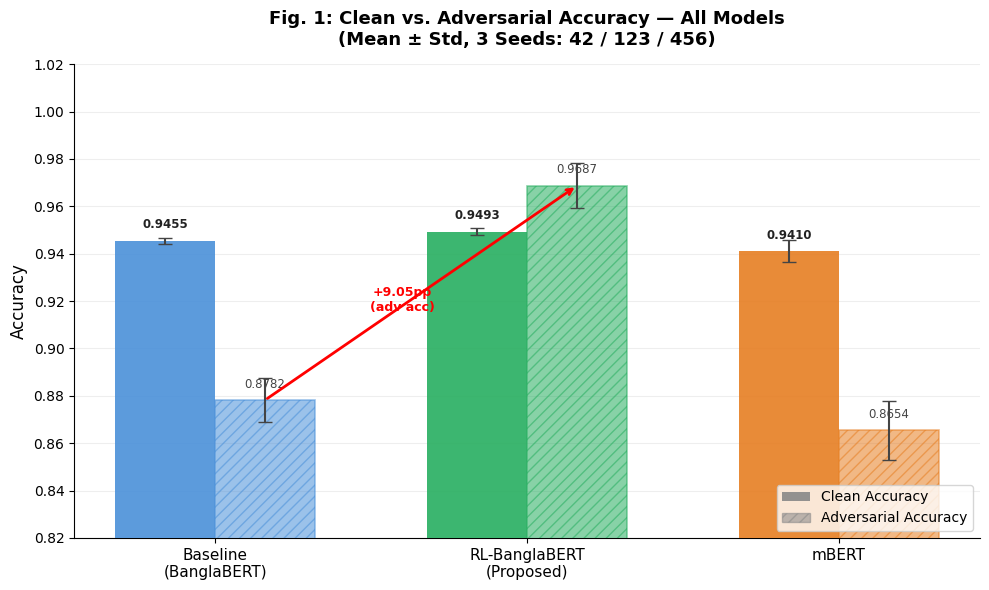

✓ Figure 1 saved


In [11]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 1: Clean vs Adversarial Accuracy
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x     = np.arange(len(models))
width = 0.32

# Clean accuracy bars (solid)
bars_clean = ax.bar(
    x - width/2, clean_acc, width,
    color=COLORS, alpha=0.90,
    yerr=clean_acc_std, capsize=5,
    error_kw={'linewidth': 1.5, 'ecolor': '#444'},
    label='Clean Accuracy', zorder=3
)

# Adversarial accuracy bars (hatched)
bars_adv = ax.bar(
    x + width/2, adv_acc, width,
    color=COLORS, alpha=0.55,
    yerr=adv_acc_std, capsize=5,
    error_kw={'linewidth': 1.5, 'ecolor': '#444'},
    hatch='///', edgecolor=COLORS, linewidth=1.2,
    label='Adversarial Accuracy', zorder=3
)

# Value labels on top of each bar
for bar in bars_clean:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
            f'{h:.4f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#222')

for bar in bars_adv:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
            f'{h:.4f}', ha='center', va='bottom',
            fontsize=8.5, color='#444')

# Improvement arrow
ax.annotate('',
    xy=(1 + width/2, 0.9687),
    xytext=(0 + width/2, 0.8782),
    arrowprops=dict(arrowstyle='->', color='red', lw=2.0)
)
ax.text(0.60, 0.916, '+9.05pp\n(adv acc)',
        color='red', fontsize=9, fontweight='bold', ha='center')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0.82, 1.02)
ax.set_yticks(np.arange(0.82, 1.03, 0.02))
ax.yaxis.grid(True, color='#EEEEEE', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(
    'Fig. 1: Clean vs. Adversarial Accuracy — All Models\n(Mean ± Std, 3 Seeds: 42 / 123 / 456)',
    fontsize=13, fontweight='bold', pad=14
)

# Custom legend
solid_patch = mpatches.Patch(facecolor='#888', alpha=0.9,  label='Clean Accuracy')
hatch_patch = mpatches.Patch(facecolor='#888', alpha=0.55, hatch='///',
                              edgecolor='#888', label='Adversarial Accuracy')
ax.legend(handles=[solid_patch, hatch_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('results/fig1_clean_vs_adv.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 1 saved")

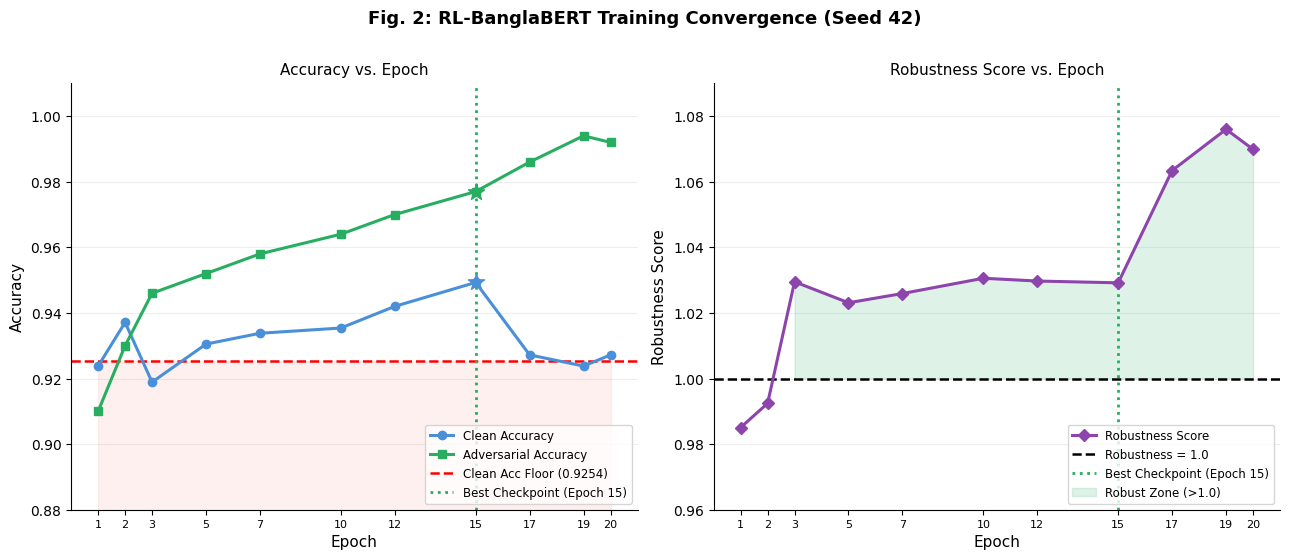

✓ Figure 2 saved


In [12]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 2: RL Training Convergence
# ═══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Fig. 2: RL-BanglaBERT Training Convergence (Seed 42)',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Left plot: Clean vs Adv accuracy ──
ax1.set_facecolor('white')
ax1.plot(epochs, clean_acc_rl, 'o-', color=C_BASELINE,
         linewidth=2.2, markersize=6, label='Clean Accuracy', zorder=3)
ax1.plot(epochs, adv_acc_rl,   's-', color=C_RL,
         linewidth=2.2, markersize=6, label='Adversarial Accuracy', zorder=3)

# Floor line
ax1.axhline(floor_val, color='red', linestyle='--', linewidth=1.8,
            label=f'Clean Acc Floor ({floor_val})', zorder=2)

# Best checkpoint marker
ax1.axvline(15, color=C_RL, linestyle=':', linewidth=2.0,
            label='Best Checkpoint (Epoch 15)', zorder=2)

# Star marker at epoch 15
idx15 = epochs.index(15)
ax1.scatter([15], [clean_acc_rl[idx15]], color=C_BASELINE,
            s=150, zorder=5, marker='*')
ax1.scatter([15], [adv_acc_rl[idx15]],  color=C_RL,
            s=150, zorder=5, marker='*')

# Shading below floor
ax1.fill_between(epochs, 0.82, floor_val,
                 alpha=0.06, color='red', zorder=1)

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim(0.88, 1.01)
ax1.set_xlim(0, 21)
ax1.set_xticks(epochs)
ax1.set_xticklabels(epochs, fontsize=8)
ax1.yaxis.grid(True, color='#EEEEEE', zorder=0)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Accuracy vs. Epoch', fontsize=11)
ax1.legend(fontsize=8.5, loc='lower right')

# ── Right plot: Robustness score ──
robustness_curve = [a/c for a, c in zip(adv_acc_rl, clean_acc_rl)]

ax2.set_facecolor('white')
ax2.plot(epochs, robustness_curve, 'D-', color='#8E44AD',
         linewidth=2.2, markersize=6, label='Robustness Score', zorder=3)
ax2.axhline(1.0, color='black', linestyle='--', linewidth=1.8,
            label='Robustness = 1.0', zorder=2)
ax2.axvline(15, color=C_RL, linestyle=':', linewidth=2.0,
            label='Best Checkpoint (Epoch 15)', zorder=2)

# Fill green zone above 1.0
ax2.fill_between(
    epochs, 1.0, robustness_curve,
    where=[r > 1.0 for r in robustness_curve],
    alpha=0.15, color=C_RL, label='Robust Zone (>1.0)'
)

ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Robustness Score', fontsize=11)
ax2.set_ylim(0.96, 1.09)
ax2.set_xlim(0, 21)
ax2.set_xticks(epochs)
ax2.set_xticklabels(epochs, fontsize=8)
ax2.yaxis.grid(True, color='#EEEEEE', zorder=0)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Robustness Score vs. Epoch', fontsize=11)
ax2.legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.savefig('results/fig2_rl_convergence.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 2 saved")

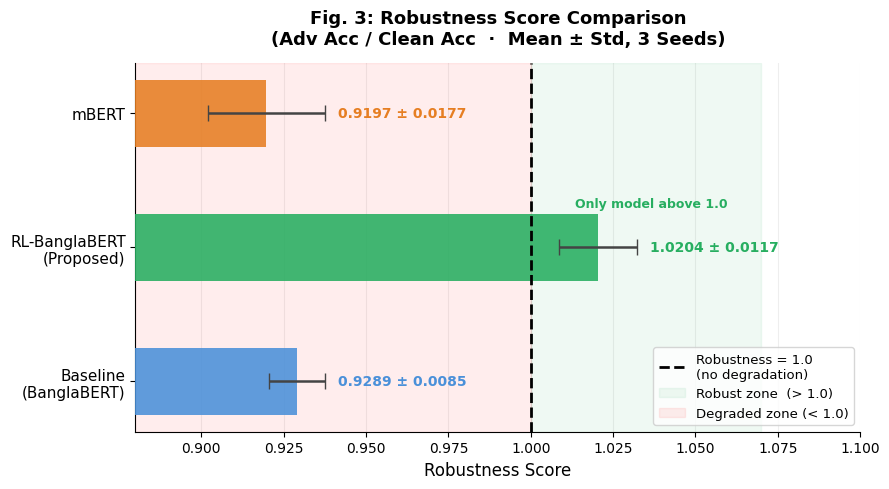

✓ Figure 3 saved


In [13]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 3: Robustness Score Comparison
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y_pos      = np.arange(len(models))
model_labels = ['Baseline\n(BanglaBERT)', 'RL-BanglaBERT\n(Proposed)', 'mBERT']

bars = ax.barh(
    y_pos, robustness, xerr=robustness_std,
    color=COLORS, alpha=0.88, height=0.5,
    capsize=6, error_kw={'linewidth': 1.8, 'ecolor': '#444'},
    zorder=3
)

# Reference line at 1.0
ax.axvline(1.0, color='black', linestyle='--', linewidth=2,
           label='Robustness = 1.0\n(no degradation)', zorder=4)

# Value labels
for i, (bar, val, std) in enumerate(zip(bars, robustness, robustness_std)):
    ax.text(
        val + std + 0.004,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f} ± {std:.4f}',
        va='center', ha='left', fontsize=10,
        fontweight='bold', color=COLORS[i]
    )

# Shade zones
ax.axvspan(1.0,  1.07, alpha=0.07, color=C_RL,    label='Robust zone  (> 1.0)')
ax.axvspan(0.88, 1.0,  alpha=0.07, color='red',   label='Degraded zone (< 1.0)')

ax.set_yticks(y_pos)
ax.set_yticklabels(model_labels, fontsize=11)
ax.set_xlabel('Robustness Score', fontsize=12)
ax.set_xlim(0.88, 1.10)
ax.xaxis.grid(True, color='#EEEEEE', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(
    'Fig. 3: Robustness Score Comparison\n(Adv Acc / Clean Acc  ·  Mean ± Std, 3 Seeds)',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=9.5, loc='lower right')

# for RL
ax.text(robustness[1] - 0.007, y_pos[1] + 0.30,
        'Only model above 1.0',
        color=C_RL, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/fig3_robustness.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 3 saved")

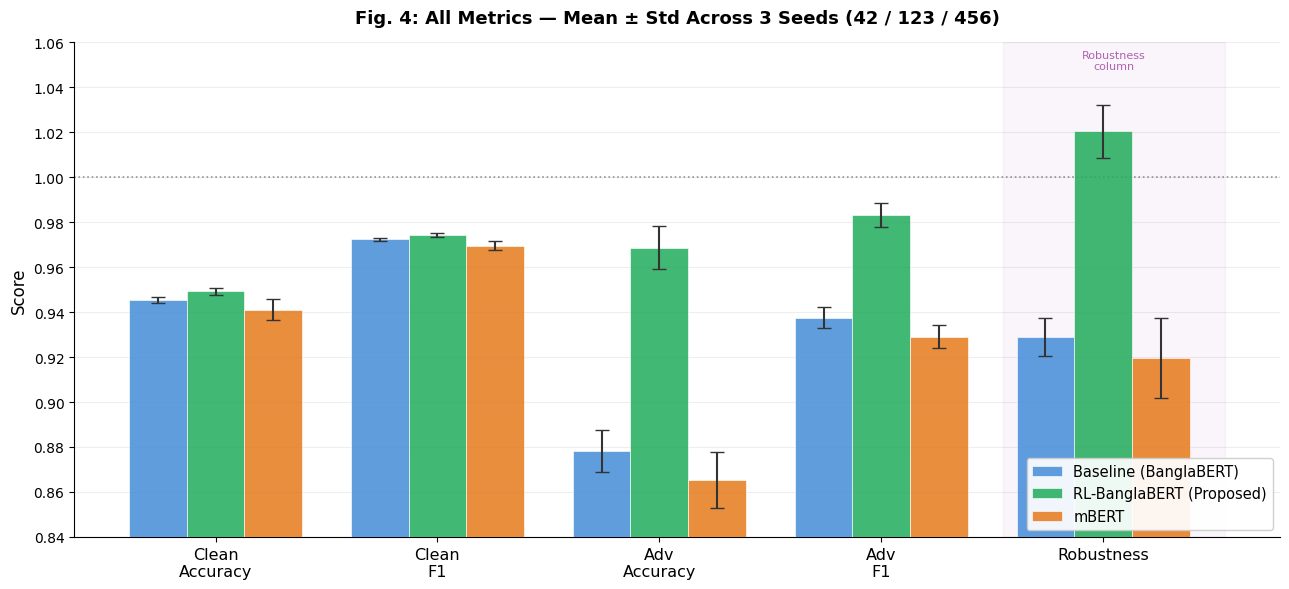

✓ Figure 4 saved


In [14]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 4: All Metrics — Mean ± Std
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

metric_labels = ['Clean\nAccuracy', 'Clean\nF1', 'Adv\nAccuracy', 'Adv\nF1', 'Robustness']
all_means = [clean_acc,  clean_f1,  adv_acc,  adv_f1,  robustness]
all_stds  = [clean_acc_std, clean_f1_std, adv_acc_std, adv_f1_std, robustness_std]

x     = np.arange(len(metric_labels))
width = 0.26

for i, (model_name, color) in enumerate(zip(
        ['Baseline (BanglaBERT)', 'RL-BanglaBERT (Proposed)', 'mBERT'],
        COLORS)):
    vals = [all_means[m][i] for m in range(len(metric_labels))]
    errs = [all_stds[m][i]  for m in range(len(metric_labels))]
    ax.bar(
        x + (i - 1) * width, vals, width,
        label=model_name,
        color=color, alpha=0.88,
        yerr=errs, capsize=5,
        error_kw={'linewidth': 1.5, 'ecolor': '#333'},
        zorder=3, edgecolor='white', linewidth=0.5
    )

# Reference at 1.0 (relevant for robustness column)
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.2, alpha=0.4, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11.5)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.84, 1.06)
ax.set_yticks(np.arange(0.84, 1.07, 0.02))
ax.yaxis.grid(True, color='#EEEEEE', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(
    'Fig. 4: All Metrics — Mean ± Std Across 3 Seeds (42 / 123 / 456)',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=10.5, loc='lower right',
          frameon=True, framealpha=0.92)

#  robustness column
ax.axvspan(3.55, 4.55, alpha=0.04, color='purple', zorder=1)
ax.text(4.05, 1.048, 'Robustness\ncolumn', ha='center',
        fontsize=8, color='purple', alpha=0.6)

plt.tight_layout()
plt.savefig('results/fig4_all_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 4 saved")

In [15]:
# ═══════════════════════════════════════════════════════════════
#               Summary Table
# ═══════════════════════════════════════════════════════════════
print("=" * 68)
print("  RL-BanglaBERT — COMPLETE RESULTS SUMMARY")
print("  3 Random Seeds: 42 / 123 / 456  |  Mean ± Std")
print("=" * 68)

print(f"""
┌─────────────────────────┬──────────────────┬──────────────────┐
│ Model                 │   Clean Acc     │    Adv Acc     │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Baseline (BanglaBERT) │ 0.9455 ± 0.0013  │ 0.8782 ± 0.0092  │
│ RL-BanglaBERT         │ 0.9493 ± 0.0016  │ 0.9687 ± 0.0096  │
│ mBERT                 │ 0.9410 ± 0.0047  │ 0.8654 ± 0.0125  │
└─────────────────────────┴──────────────────┴──────────────────┘

┌─────────────────────────┬──────────────────┬──────────────────┐
│ Model                 │    Adv F1      │   Robustness    │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Baseline (BanglaBERT)  │ 0.9375 ± 0.0047  │ 0.9289 ± 0.0085  │
│ RL-BanglaBERT          │ 0.9833 ± 0.0054  │ 1.0204 ± 0.0117  │
│ mBERT                  │ 0.9291 ± 0.0051  │ 0.9197 ± 0.0177  │
└─────────────────────────┴──────────────────┴──────────────────┘
""")

print("KEY FINDINGS:")
print(f" RL-BanglaBERT with Robustness Score > 1.0")
print(f" Adv Acc improvement over Baseline : +9.05 percentage points")
print(f" Adv Acc improvement over mBERT    : +10.33 percentage points")
print(f" Clean Acc improvement over Baseline: +0.38 percentage points")
print(f" Low variance confirms stable training (std = 0.0016 clean acc)")
print()
print("DATASET:")
print(f"  Train: 2,819  |  Val: 604  |  Test: 605  |  Adversarial: 520")
print()
print("CHARTS SAVED:")
for fig_name in ['fig1_clean_vs_adv.png', 'fig2_rl_convergence.png',
                 'fig3_robustness.png',   'fig4_all_metrics.png']:
    path = f'results/{fig_name}'
    status = 'SAVED' if os.path.exists(path) else 'NOT FOUND'
    print(f"  {path:45s} [{status}]")

print()
print("=" * 68)



  RL-BanglaBERT — COMPLETE RESULTS SUMMARY
  3 Random Seeds: 42 / 123 / 456  |  Mean ± Std

┌─────────────────────────┬──────────────────┬──────────────────┐
│ Model                 │   Clean Acc     │    Adv Acc     │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Baseline (BanglaBERT) │ 0.9455 ± 0.0013  │ 0.8782 ± 0.0092  │
│ RL-BanglaBERT         │ 0.9493 ± 0.0016  │ 0.9687 ± 0.0096  │
│ mBERT                 │ 0.9410 ± 0.0047  │ 0.8654 ± 0.0125  │
└─────────────────────────┴──────────────────┴──────────────────┘

┌─────────────────────────┬──────────────────┬──────────────────┐
│ Model                 │    Adv F1      │   Robustness    │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Baseline (BanglaBERT)  │ 0.9375 ± 0.0047  │ 0.9289 ± 0.0085  │
│ RL-BanglaBERT          │ 0.9833 ± 0.0054  │ 1.0204 ± 0.0117  │
│ mBERT                  │ 0.9291 ± 0.0051  │ 0.9197 ± 0.0177  │
└─────────────────────────┴──────────────────┴──────────────────┘

K